> **Note:** This notebook depends on variables created in `01_cleaning.ipynb` (`combined_df`, `model_df`, neighbourhood sub-DataFrames) and visualisations from `02_eda.ipynb`. Run `01_cleaning.ipynb` first in the same session.

# 4. Modeling

## 4.1 Decision Tree Regressor

We have trained a predictive analytics model using a Decision Tree Regressor to map out predicted revenue of a rental using the following features, provided by the listing on Airbnb.

*   Number of beds (options: 0, 1, 2, 3, 4, 5)
*   Number of baths (options: 1.0, 1.5, 2.0, 2.5, 3.0, 3.5)
*   Neighbourhoods (inputted using dummy variables)
*     Exposition Park
*     Hollywood Hills
*     Inglewood
*     Pasadena
*     Downtown


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score



X = model_df[['bedrooms', 'bathrooms',
                               'neighbourhood_cleansed_Exposition Park',
                               'neighbourhood_cleansed_Hollywood Hills',
                               'neighbourhood_cleansed_Inglewood',
                               'neighbourhood_cleansed_Pasadena',
                               'neighbourhood_cleansed_Downtown']].values
y = model_df[['revenue']].values

#split data into training and testing sets, 20% test size
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,
                                                    shuffle = True,
                                                    random_state = 42)

#4. choose and train a model
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)


# Bedroom and bathroom options
bedroom_options = [0, 1, 2, 3, 4, 5]
bathroom_options = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
neighbourhoods = ['Exposition Park', 'Hollywood Hills', 'Inglewood', 'Pasadena', 'Downtown']

# Generate all combinations of bedrooms, bathrooms, and neighbourhoods
combinations = []
for neigh in neighbourhoods:
    for bed in bedroom_options:
        for bath in bathroom_options:
            combinations.append((bed, bath, neigh))

# Prepare input for the model
# Assuming your model expects one-hot encoded neighbourhood columns:
neigh_columns = ['neighbourhood_cleansed_Exposition Park',
                 'neighbourhood_cleansed_Hollywood Hills',
                 'neighbourhood_cleansed_Inglewood',
                 'neighbourhood_cleansed_Pasadena',
                 'neighbourhood_cleansed_Downtown']

X_pred = []
for bed, bath, neigh in combinations:
    # Create one-hot encoding for neighbourhood
    one_hot = [1 if n == neigh else 0 for n in neighbourhoods]
    X_pred.append([bed, bath] + one_hot)

X_pred = np.array(X_pred)

# Predict revenue for all combinations
projected_rev = model.predict(X_pred)

# Split combinations for DataFrame
beds = [c[0] for c in combinations]
baths = [c[1] for c in combinations]
neighs = [c[2] for c in combinations]

# Create DataFrame
decision_tree_regressor_df = pd.DataFrame({
    'Bedrooms': beds,
    'Bathrooms': baths,
    'Neighbourhood': neighs,
    'Projected Revenue': projected_rev
})

print("Projection of Combinations:")
print(decision_tree_regressor_df)

# Make predictions
y_pred = model.predict(X_test)

# Regression metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Evaluation on Test Set:")
print(f"MAE:  {mae}")
print(f"MSE:  {mse}")
print(f"RMSE: {rmse}")
print(f"R²:   {r2}")

# Cross-validation for regression
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² scores for each fold:", cv_scores)
print("Average CV R²:", np.mean(cv_scores))


Projection of Combinations:
     Bedrooms  Bathrooms    Neighbourhood  Projected Revenue
0           0        1.0  Exposition Park       10363.722222
1           0        1.5  Exposition Park           0.000000
2           0        2.0  Exposition Park           0.000000
3           0        2.5  Exposition Park        6200.000000
4           0        3.0  Exposition Park        6200.000000
..        ...        ...              ...                ...
175         5        1.5         Downtown       49392.000000
176         5        2.0         Downtown           0.000000
177         5        2.5         Downtown       81439.500000
178         5        3.0         Downtown        1730.181818
179         5        3.5         Downtown           0.000000

[180 rows x 4 columns]
Evaluation on Test Set:
MAE:  18768.181914688303
MSE:  1171225623.0321195
RMSE: 34223.17377205275
R²:   -0.10134450455470634

Cross-validation R² scores for each fold: [-0.1013445  -0.02027656 -0.14745819 -0.71383167

These evaluation metrics indicate that the model does not fully capture the variability in revenue. However,  because of the intended simplicity of the model and the limited feature set used, this is understandable.

Our primary goal was to maintain a simple model to understand how certain features like bedrooms, bathrooms, and neighborhood contribute to projected revenue. While more complex models with more features could improve these stats, this approach prioritizes interpretability over maximum performance in relevence to our key attributes.

## 4.1.1 Understanding How the Model Makes Decisions – SHAP Analysis

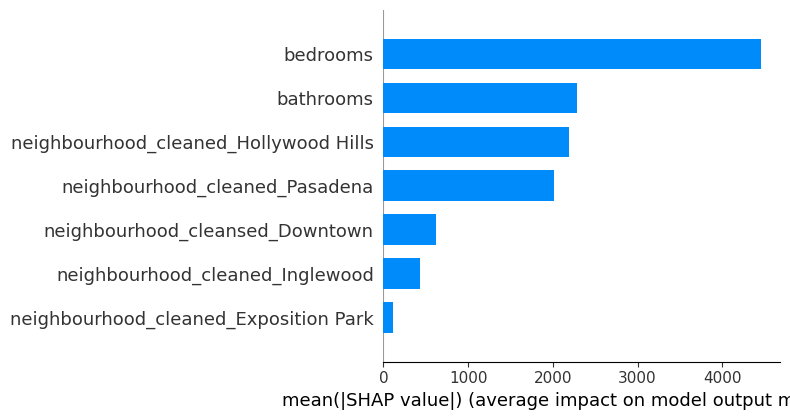

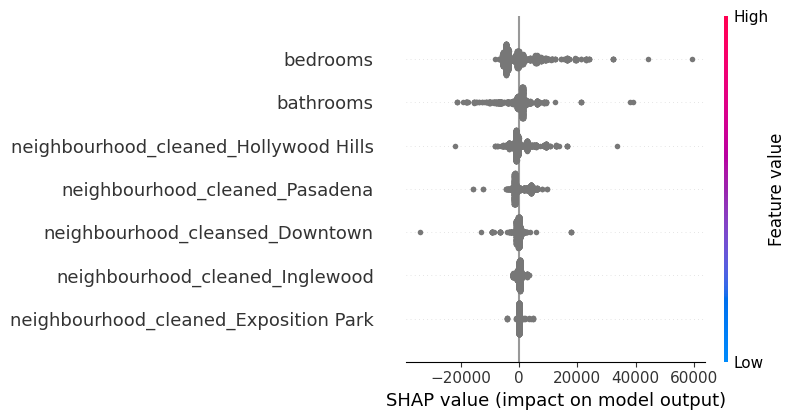

In [ ]:
# Import shap library
import shap

# Create a list with all relevant features
feature_names = [
    'bedrooms',
    'bathrooms',
    'neighbourhood_cleaned_Exposition Park',
    'neighbourhood_cleaned_Hollywood Hills',
    'neighbourhood_cleaned_Inglewood',
    'neighbourhood_cleaned_Pasadena',
    'neighbourhood_cleansed_Downtown'
]

# convert training data into a pandas DataFrame
X_train_df = pd.DataFrame(X_train, columns=feature_names)

# Create a shap explainer and calculate the shap values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_df)

# Create a bar chart that shows the overall importance of each feature
shap.summary_plot(shap_values, X_train_df, plot_type="bar")
# Create a detailed summary plot showing how each feature affects predictions
shap.summary_plot(shap_values, X_train_df)


The first plot shows which variables that has the most effect overall on the mdoel. Bedrooms are the most important, followed by bathrooms and the neighbourhoods of Hollywood Hills and Pasadena. Neighbourhoods like Inglewood and Exposition park has a low affect on the model.



The scatter plot shows how each variable affects the prediction for each individual property. Points to the right indicate that the feature increases the predicted price or revenue, while points to the left indicate that it decreases it. For example, having more bedrooms usually leads to a higher predicted value, but the impact is not the same for every property.

**SHAP-summary for Pasadena: how bedrooms and bathrooms affect the revenue**

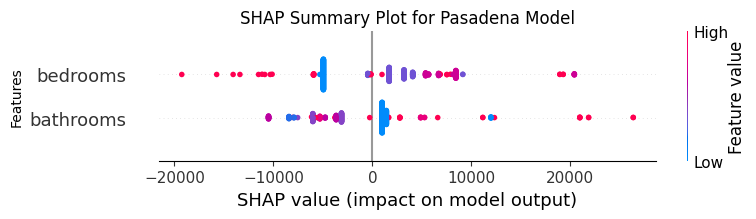

Evaluation on Test Set:
PasadenaMAE:  15198.518971344549
PasadenaMSE:  321330106.90663415
PasadenaRMSE: 17925.682885364065
Pasadena R²:   -0.3091232943234634

Pasadena Cross-validation R² scores for each fold: [-0.30912329 -0.21016311 -0.67347886 -0.30612867 -0.18443502]
Pasadena Average CV R²: -0.3366657928054019


In [ ]:
# Features and target
Pasadena_X = pasadena_df[['bedrooms', 'bathrooms']].values
Pasadena_y = pasadena_df[['revenue']].values

# Train-test split
Pasadena_X_train, Pasadena_X_test, Pasadena_y_train, Pasadena_y_test = train_test_split(
    Pasadena_X, Pasadena_y, test_size=0.2, shuffle=True, random_state=42
)

# Train model
Pasadena_model = DecisionTreeRegressor(random_state=42)
Pasadena_model.fit(Pasadena_X_train, Pasadena_y_train)

# Bedroom and bathroom options
bedroom_options = [0, 1, 2, 3, 4, 5]
bathroom_options = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]

# Generate all combinations
bed_bath_combinations = [(bed, bath) for bed in bedroom_options for bath in bathroom_options]

# Prepare input array for prediction
Pasadena_X_pred = np.array(bed_bath_combinations)

# Predict revenue
Pasadena_projected_rev = Pasadena_model.predict(Pasadena_X_pred)

# Split combinations for DataFrame
beds = [c[0] for c in bed_bath_combinations]
baths = [c[1] for c in bed_bath_combinations]

# Create DataFrame
Pasadena_decision_tree_regressor_df = pd.DataFrame({
    'Bedrooms': beds,
    'Bathrooms': baths,
    'Projected Revenue': Pasadena_projected_rev
})

#SHAP summary Pasadena
feature_names = [
    'bedrooms',
    'bathrooms'
]

Pasadena_X_train_df = pd.DataFrame(Pasadena_X_train, columns=feature_names)

Pasadena_explainer = shap.TreeExplainer(Pasadena_model)
Pasadena_shap_values = Pasadena_explainer.shap_values(Pasadena_X_train_df)

# Customise plot
plt.title("SHAP Summary Plot for Pasadena Model")
plt.xlabel("SHAP Value Impact on Revenue")
plt.ylabel("Features")

shap.summary_plot(Pasadena_shap_values, Pasadena_X_train_df, sort=False)

Pasadena_y_pred = Pasadena_model.predict(Pasadena_X_test)

# Regression metrics
Pasadena_mae = mean_absolute_error(Pasadena_y_test, Pasadena_y_pred)
Pasadena_mse = mean_squared_error(Pasadena_y_test, Pasadena_y_pred)
Pasadena_rmse = np.sqrt(Pasadena_mse)
Pasadena_r2 = r2_score(Pasadena_y_test, Pasadena_y_pred)

print("Evaluation on Test Set:")
print(f"PasadenaMAE:  {Pasadena_mae}")
print(f"PasadenaMSE:  {Pasadena_mse}")
print(f"PasadenaRMSE: {Pasadena_rmse}")
print(f"Pasadena R²:   {Pasadena_r2}")

# Cross-validation for regression
Pasadena_kf = KFold(n_splits=5, shuffle=True, random_state=42)
Pasadena_cv_scores = cross_val_score(Pasadena_model, Pasadena_X, Pasadena_y, cv=Pasadena_kf, scoring='r2')

print("\nPasadena Cross-validation R² scores for each fold:", Pasadena_cv_scores)
print("Pasadena Average CV R²:", np.mean(Pasadena_cv_scores))



**SHAP-summary for Downtown  LA: how bedrooms and bathrooms affect the revenue**

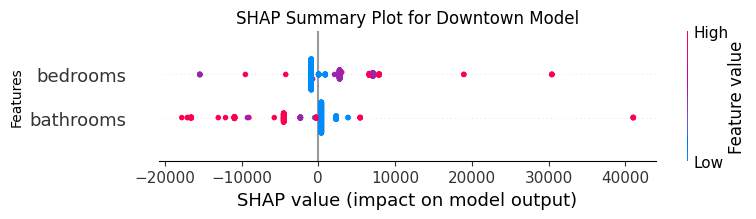

Evaluation on Test Set:
Downtown MAE:  9927.241511057638
Downtown MSE:  141424415.16794387
Downtown RMSE: 11892.199761521997
Downtown R²:   0.030213683116725454

Downtown Cross-validation R² scores for each fold: [ 0.03021368 -0.24619392 -0.0580299  -0.04013326  0.02629207]
Downtown Average CV R²: -0.05757026479367464


In [ ]:
# Features and target
Downtown_X = downtown_df[['bedrooms', 'bathrooms']].values
Downtown_y = downtown_df[['revenue']].values

# Train-test split
Downtown_X_train, Downtown_X_test, Downtown_y_train, Downtown_y_test = train_test_split(
    Downtown_X, Downtown_y, test_size=0.2, shuffle=True, random_state=42
)

# Train model
Downtown_model = DecisionTreeRegressor(random_state=42)
Downtown_model.fit(Downtown_X_train, Downtown_y_train)

# Bedroom and bathroom options
bedroom_options = [0, 1, 2, 3, 4, 5]
bathroom_options = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]

# Generate all combinations
bed_bath_combinations = [(bed, bath) for bed in bedroom_options for bath in bathroom_options]

# Prepare input array for prediction
Downtown_X_pred = np.array(bed_bath_combinations)

# Predict revenue
Downtown_projected_rev = Downtown_model.predict(Downtown_X_pred)

# Split combinations for DataFrame
beds = [c[0] for c in bed_bath_combinations]
baths = [c[1] for c in bed_bath_combinations]

# Create DataFrame
Downtown_decision_tree_regressor_df = pd.DataFrame({
    'Bedrooms': beds,
    'Bathrooms': baths,
    'Projected Revenue': Downtown_projected_rev
})

#SHAP summary Pasadena
feature_names = [
    'bedrooms',
    'bathrooms'
]

Downtown_X_train_df = pd.DataFrame(Downtown_X_train, columns=feature_names)

Downtown_explainer = shap.TreeExplainer(Downtown_model)
Downtown_shap_values = Downtown_explainer.shap_values(Downtown_X_train_df)

# Customise plot
plt.title("SHAP Summary Plot for Downtown Model")
plt.xlabel("SHAP Value Impact on Revenue")
plt.ylabel("Features")

shap.summary_plot(Downtown_shap_values, Downtown_X_train_df, sort=False)

# Regression metrics
Downtown_y_pred = Downtown_model.predict(Downtown_X_test)
Downtown_mae = mean_absolute_error(Downtown_y_test, Downtown_y_pred)
Downtown_mse = mean_squared_error(Downtown_y_test, Downtown_y_pred)
Downtown_rmse = np.sqrt(Downtown_mse)
Downtown_r2 = r2_score(Downtown_y_test, Downtown_y_pred)

print(f"Evaluation on Test Set:")
print(f"Downtown MAE:  {Downtown_mae}")
print(f"Downtown MSE:  {Downtown_mse}")
print(f"Downtown RMSE: {Downtown_rmse}")
print(f"Downtown R²:   {Downtown_r2}")

# Cross-validation for regression
Downtown_kf = KFold(n_splits=5, shuffle=True, random_state=42)
Downtown_cv_scores = cross_val_score(Downtown_model, Downtown_X, Downtown_y, cv=Downtown_kf, scoring='r2')

print("\nDowntown Cross-validation R² scores for each fold:", Downtown_cv_scores)
print("Downtown Average CV R²:", np.mean(Downtown_cv_scores))


**SHAP-summary for Hollywood Hills: how bedrooms and bathrooms affect the revenue**

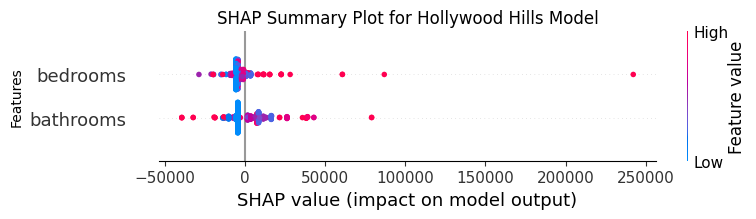

Evaluation on Test Set:
Downtown MAE:  25669.61567298199
Downtown MSE:  1212378484.48445
Downtown RMSE: 34819.2257881253
Downtown R²:   -0.10407973987352914

Hollywood Hills Cross-validation R² scores for each fold: [-0.10407974 -0.65917543 -0.13097726 -0.18305085 -0.13506739]
Hollywood Hills Average CV R²: -0.24247013347613522


In [ ]:
# Features and target
hollywood_hills_X = hollywood_hills_df[['bedrooms', 'bathrooms']].values
hollywood_hills_y = hollywood_hills_df[['revenue']].values

# Train-test split
hollywood_hills_X_train, hollywood_hills_X_test, hollywood_hills_y_train, hollywood_hills_y_test = train_test_split(
    hollywood_hills_X, hollywood_hills_y, test_size=0.2, shuffle=True, random_state=42
)

# Train model
hollywood_hills_model = DecisionTreeRegressor(random_state=42)
hollywood_hills_model.fit(hollywood_hills_X_train, hollywood_hills_y_train)

# Bedroom and bathroom options
bedroom_options = [0, 1, 2, 3, 4, 5]
bathroom_options = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]

# Generate all combinations
bed_bath_combinations = [(bed, bath) for bed in bedroom_options for bath in bathroom_options]

# Prepare input array for prediction
hollywood_hills_X_pred = np.array(bed_bath_combinations)

# Predict revenue
hollywood_hills_projected_rev = hollywood_hills_model.predict(hollywood_hills_X_pred)

# Split combinations for DataFrame
beds = [c[0] for c in bed_bath_combinations]
baths = [c[1] for c in bed_bath_combinations]

# Create DataFrame
hollywood_hills_decision_tree_regressor_df = pd.DataFrame({
    'Bedrooms': beds,
    'Bathrooms': baths,
    'Projected Revenue': hollywood_hills_projected_rev
})



#SHAP summary Hollywoo Hills
feature_names = [
    'bedrooms',
    'bathrooms'
]

hollywood_hills_X_train_df = pd.DataFrame(hollywood_hills_X_train, columns=feature_names)


hollywood_hills_explainer = shap.TreeExplainer(hollywood_hills_model)
hollywood_hills_shap_values = hollywood_hills_explainer.shap_values(hollywood_hills_X_train_df)


# Customise plot
plt.title("SHAP Summary Plot for Hollywood Hills Model")
plt.xlabel("SHAP Value Impact on Revenue")
plt.ylabel("Features")

shap.summary_plot(hollywood_hills_shap_values, hollywood_hills_X_train_df, sort=False)

# Regression metrics
hollywood_hills_y_pred = hollywood_hills_model.predict(hollywood_hills_X_test)
hollywood_hills_mae = mean_absolute_error(hollywood_hills_y_test, hollywood_hills_y_pred)
hollywood_hills_mse = mean_squared_error(hollywood_hills_y_test, hollywood_hills_y_pred)
hollywood_hills_rmse = np.sqrt(hollywood_hills_mse)
hollywood_hills_r2 = r2_score(hollywood_hills_y_test, hollywood_hills_y_pred)

print("Evaluation on Test Set:")
print(f"Downtown MAE:  {hollywood_hills_mae}")
print(f"Downtown MSE:  {hollywood_hills_mse}")
print(f"Downtown RMSE: {hollywood_hills_rmse}")
print(f"Downtown R²:   {hollywood_hills_r2}")

# Cross-validation for regression
hollywood_hills_kf = KFold(n_splits=5, shuffle=True, random_state=42)
hollywood_hills_cv_scores = cross_val_score(hollywood_hills_model, hollywood_hills_X, hollywood_hills_y, cv=hollywood_hills_kf, scoring='r2')

print("\nHollywood Hills Cross-validation R² scores for each fold:", hollywood_hills_cv_scores)
print("Hollywood Hills Average CV R²:", np.mean(hollywood_hills_cv_scores))

**SHAP-summary for Exposition Park: how bedrooms and bathrooms affect the revenue**

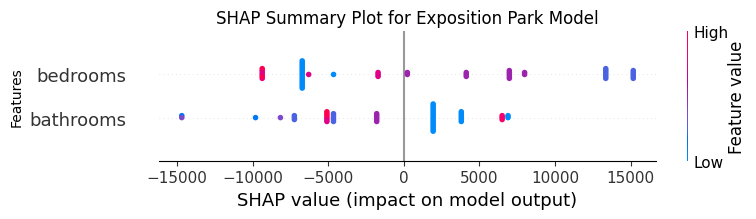

Evaluation on Test Set:
Downtown MAE:  11238.374358974359
Downtown MSE:  320964138.3155556
Downtown RMSE: 17915.472037196105
Downtown R²:   -0.008974675528554243

Exposition Park Cross-validation R² scores for each fold: [-0.00897468  0.2430178  -0.65577658 -0.18060804 -0.1928867 ]
Exposition Park Average CV R²: -0.1590456395031052


In [ ]:
# Features and target
exposition_park_X = exposition_park_df[['bedrooms', 'bathrooms']].values
exposition_park_y = exposition_park_df[['revenue']].values

# Train-test split
exposition_park_X_train, exposition_park_X_test, exposition_park_y_train, exposition_park_y_test = train_test_split(
    exposition_park_X, exposition_park_y, test_size=0.2, shuffle=True, random_state=42
)

# Train model
exposition_park_model = DecisionTreeRegressor(random_state=42)
exposition_park_model.fit(exposition_park_X_train, exposition_park_y_train)

# Bedroom and bathroom options
bedroom_options = [0, 1, 2, 3, 4, 5]
bathroom_options = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]

# Generate all combinations
bed_bath_combinations = [(bed, bath) for bed in bedroom_options for bath in bathroom_options]

# Prepare input array for prediction
exposition_park_X_pred = np.array(bed_bath_combinations)

# Predict revenue
exposition_park_projected_rev = exposition_park_model.predict(exposition_park_X_pred)

# Split combinations for DataFrame
beds = [c[0] for c in bed_bath_combinations]
baths = [c[1] for c in bed_bath_combinations]

# Create DataFrame
exposition_park_decision_tree_regressor_df = pd.DataFrame({
    'Bedrooms': beds,
    'Bathrooms': baths,
    'Projected Revenue': exposition_park_projected_rev
})


#SHAP summary Exposition Park
feature_names = [
    'bedrooms',
    'bathrooms'
]

exposition_park_X_train_df = pd.DataFrame(exposition_park_X_train, columns=feature_names)

exposition_park_explainer = shap.TreeExplainer(exposition_park_model)
exposition_park_shap_values = exposition_park_explainer.shap_values(exposition_park_X_train_df)

# Customise plot
plt.title("SHAP Summary Plot for Exposition Park Model")
plt.xlabel("SHAP Value Impact on Revenue")
plt.ylabel("Features")

shap.summary_plot(exposition_park_shap_values, exposition_park_X_train_df, sort=False)

# Regression metrics
exposition_park_y_pred = exposition_park_model.predict(exposition_park_X_test)
exposition_park_mae = mean_absolute_error(exposition_park_y_test, exposition_park_y_pred)
exposition_park_mse = mean_squared_error(exposition_park_y_test, exposition_park_y_pred)
exposition_park_rmse = np.sqrt(exposition_park_mse)
exposition_park_r2 = r2_score(exposition_park_y_test, exposition_park_y_pred)

print("Evaluation on Test Set:")
print(f"Downtown MAE:  {exposition_park_mae}")
print(f"Downtown MSE:  {exposition_park_mse}")
print(f"Downtown RMSE: {exposition_park_rmse}")
print(f"Downtown R²:   {exposition_park_r2}")

# Cross-validation for regression
exposition_park_kf = KFold(n_splits=5, shuffle=True, random_state=42)
exposition_park_cv_scores = cross_val_score(exposition_park_model, exposition_park_X, exposition_park_y, cv=exposition_park_kf, scoring='r2')

print("\nExposition Park Cross-validation R² scores for each fold:", exposition_park_cv_scores)
print("Exposition Park Average CV R²:", np.mean(exposition_park_cv_scores))


**SHAP-summary for Inglewood: how bedrooms and bathrooms affect the revenue**

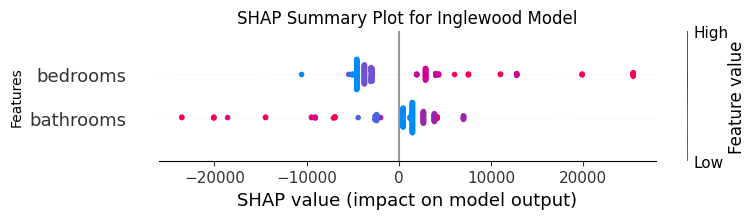

Evaluation on Test Set:
Downtown MAE:  11309.507677416024
Downtown MSE:  195917488.4803743
Downtown RMSE: 13997.052849810003
Downtown R²:   -0.3118667164447797

Inglewood Cross-validation R² scores for each fold: [-0.31186672  0.21846882 -0.49271692  0.16230506 -0.31666938]
Inglewood Average CV R²: -0.14809582625361886


In [ ]:
# Features and target
inglewood_X = inglewood_df[['bedrooms', 'bathrooms']].values
inglewood_y = inglewood_df[['revenue']].values

# Train-test split
inglewood_X_train, inglewood_X_test, inglewood_y_train, inglewood_y_test = train_test_split(
    inglewood_X, inglewood_y, test_size=0.2, shuffle=True, random_state=42
)

# Train model
inglewood_model = DecisionTreeRegressor(random_state=42)
inglewood_model.fit(inglewood_X_train, inglewood_y_train)

# Bedroom and bathroom options
bedroom_options = [0, 1, 2, 3, 4, 5]
bathroom_options = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]

# Generate all combinations
bed_bath_combinations = [(bed, bath) for bed in bedroom_options for bath in bathroom_options]

# Prepare input array for prediction
inglewood_X_pred = np.array(bed_bath_combinations)

# Predict revenue
inglewood_projected_rev = inglewood_model.predict(inglewood_X_pred)

# Split combinations for DataFrame
beds = [c[0] for c in bed_bath_combinations]
baths = [c[1] for c in bed_bath_combinations]

# Create DataFrame
inglewood_decision_tree_regressor_df = pd.DataFrame({
    'Bedrooms': beds,
    'Bathrooms': baths,
    'Projected Revenue': inglewood_projected_rev
})


#SHAP summary inglewood
feature_names = [
    'bedrooms',
    'bathrooms'
]

inglewood_X_train_df = pd.DataFrame(inglewood_X_train, columns=feature_names)


inglewood_explainer = shap.TreeExplainer(inglewood_model)
inglewood_shap_values = inglewood_explainer.shap_values(inglewood_X_train_df)

# Customise plot
plt.title("SHAP Summary Plot for Inglewood Model")
plt.xlabel("SHAP Value Impact on Revenue")
plt.ylabel("Features")

shap.summary_plot(inglewood_shap_values, inglewood_X_train_df, sort=False)


# Regression metrics
inglewood_y_pred = inglewood_model.predict(inglewood_X_test)
inglewood_mae = mean_absolute_error(inglewood_y_test, inglewood_y_pred)
inglewood_mse = mean_squared_error(inglewood_y_test, inglewood_y_pred)
inglewood_rmse = np.sqrt(inglewood_mse)
inglewood_r2 = r2_score(inglewood_y_test, inglewood_y_pred)

print("Evaluation on Test Set:")
print(f"Downtown MAE:  {inglewood_mae}")
print(f"Downtown MSE:  {inglewood_mse}")
print(f"Downtown RMSE: {inglewood_rmse}")
print(f"Downtown R²:   {inglewood_r2}")

# Cross-validation for regression
inglewood_kf = KFold(n_splits=5, shuffle=True, random_state=42)
inglewood_cv_scores = cross_val_score(inglewood_model, inglewood_X, inglewood_y, cv=inglewood_kf, scoring='r2')

print("\nInglewood Cross-validation R² scores for each fold:", inglewood_cv_scores)
print("Inglewood Average CV R²:", np.mean(inglewood_cv_scores))

### **4.1.1.2 SHAP Neighbourhood Summary Plots Analysis**
###Pasadena Model
Bedrooms:
- High quanitites (Red dots) and Low quanitites (blue dots) are spread across both the negative (left) and positive (right) sides of the average
- Having a high or low number of bedrooms can either increase or decrease the predicted price
- This large spread could be tell us that the relationship with bedrooms and revenue is not a simple linear positive one for Pasadena

Bathrooms
- High quanitites have strong impacts on both the positive and negative sides.
- Low quanitites are clustered around average

Overall: Bathrooms are the most influential feature in this plot as it has the both the largest positive and largest negative impacts.

###Downtown Model
Bedrooms
- High quantity of bedrooms are clustered mostly on the negative side
- Lower qantities are mostly on the positive side
- Having fewer bedrooms has an increased predicted output.

Bathrooms
- High quanitites are mostly on the negative side, showing a strong tendency to decrease the predicted output
- Low quanitites are mostly on the positive side, showing a tendency to increase the predicted output.

Overall: The focus for Downtown market could be explained as strongly weighted towards smaller, high-demand, high-price per square foot units (meaning and the price range has more to do other factors, such as building or area, rather than studio vs not).

###Hollywood Hills Model
Bedrooms
- High quanitites are scattered on the right, contributing to a higher predicted output
- Low quanitites are on the left, contributing to a lower predicted output

Bathrooms
- High quanititesare predominantly on the right side
- Low quanitites are centered around zero or to the left (minor impact)
- More bathrooms significantly increase the predicted output

Overall: Both bedrooms and bathrooms have stong impact; bathrooms having a much larger potential positive impact.


###Expostion Park Model
Bedrooms
- Low quanitites are generally on the right side, contributing to a higher predicted output
- High quanitites are mostly on the left side, contributing to a lower predicted output

Bathrooms
- Low quanitites are mostly on the left, lowering the predicted output.
- High quanitites are split around the average
- Relatively neutral effect

Overall: Similar to Downtown, this could be explained as a stronger market weight on smaller, high-demand, high-price per square foot units

###Inglewood Model
Bedrooms
- High quanitites are predominantly on the right side of the average, so more bedrooms increase the predicted output
- Low quanitites are mostly clustered around average or slightly to the left (so having few bedrooms has a minor prediction)

Bathrooms
- The high quanitites are primarily on the left of the average
- The low quanitites are clustered around zero/slightly right.
- Fewer bathrooms tend to have a minor overall impact

Overall: Bedrooms have exponential impact on positive revenue

## 4.1.2 Heatmap of Projected Revenue by Bedrooms and Bathrooms for all neighbourhoods

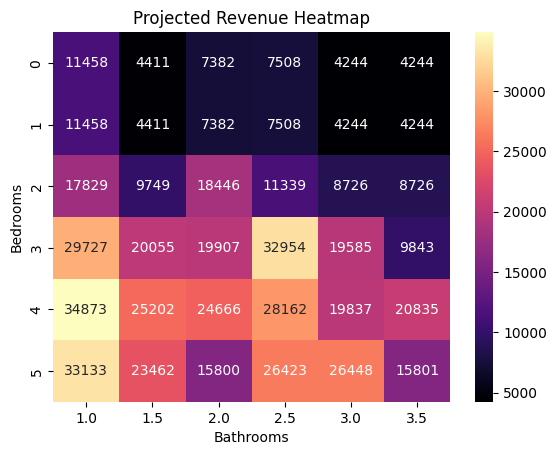

In [ ]:

# Create a pivot table
pivot = decision_tree_regressor_df.pivot_table(
    values='Projected Revenue',
    index='Bedrooms',
    columns='Bathrooms'
)

# Create a heatmap from the pivot table
sns.heatmap(pivot, annot=True, fmt=".0f",cmap ='magma')
plt.title('Projected Revenue Heatmap')
plt.show()

This heatmap shows how projected revenue varies depending on the number of bedrooms and bathrooms

For example, properties with 0 bedrooms and 1 bathroom are projected to earn around 11,458, which is relatively low compared to larger properties. When you move to 3 bedrooms and 2.5 bathrooms, the projected revenue increases significantly to about 32,954. The highest value appears at 4 bedrooms and 1 bathroom, with a projected revenue of around 34,873, showing that larger homes generally earn more.

## 4.1.3 Heatmap of Projected Revenue by Bedrooms and Bathrooms for each neighbourhood

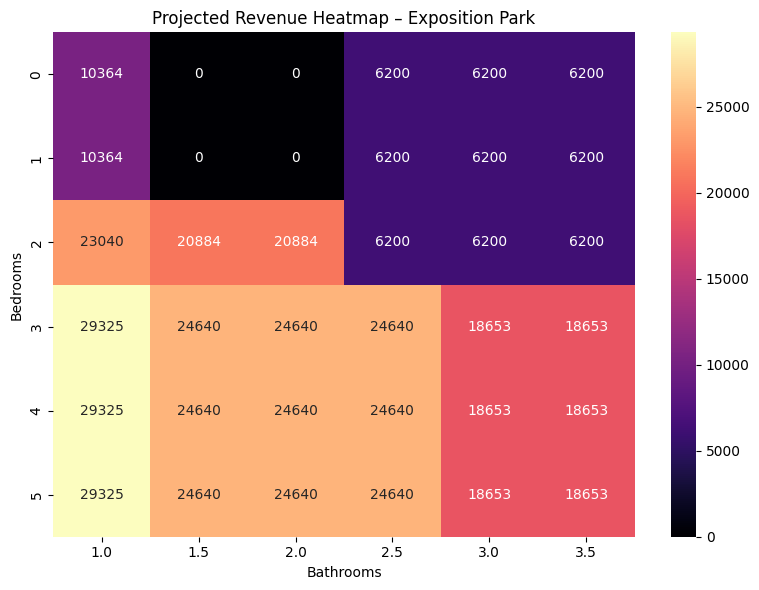

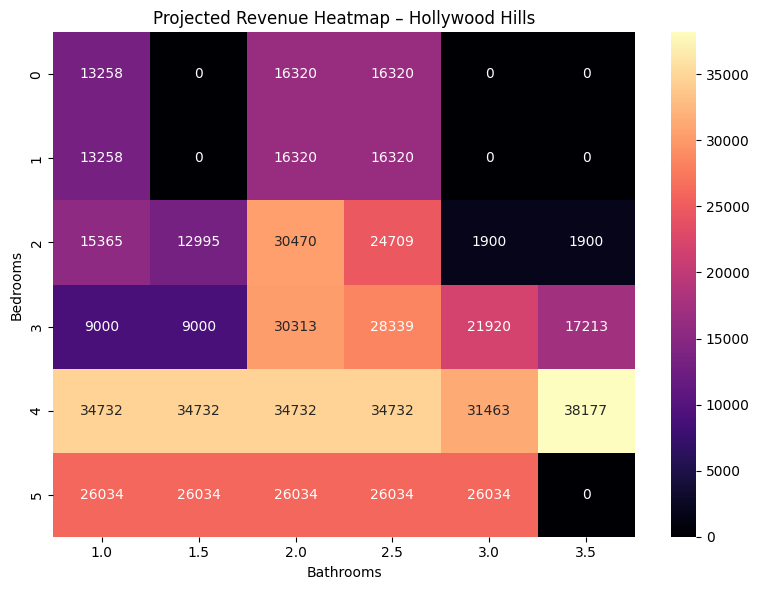

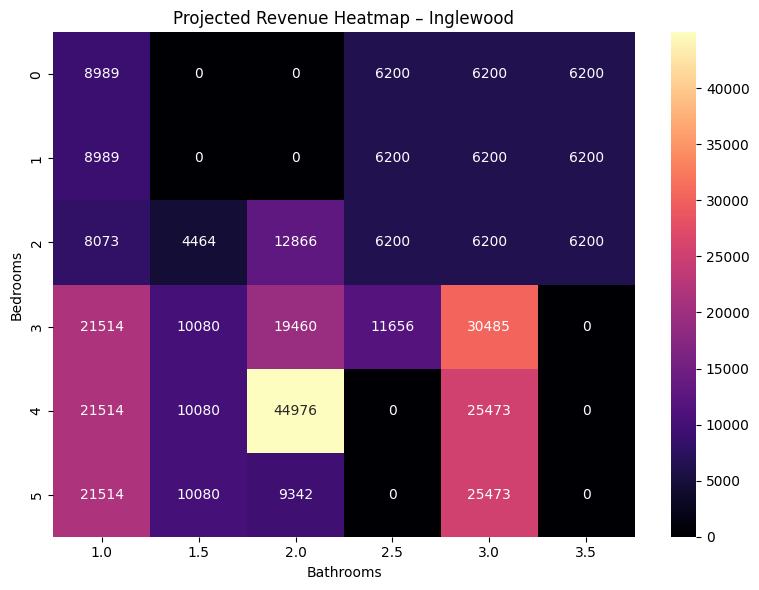

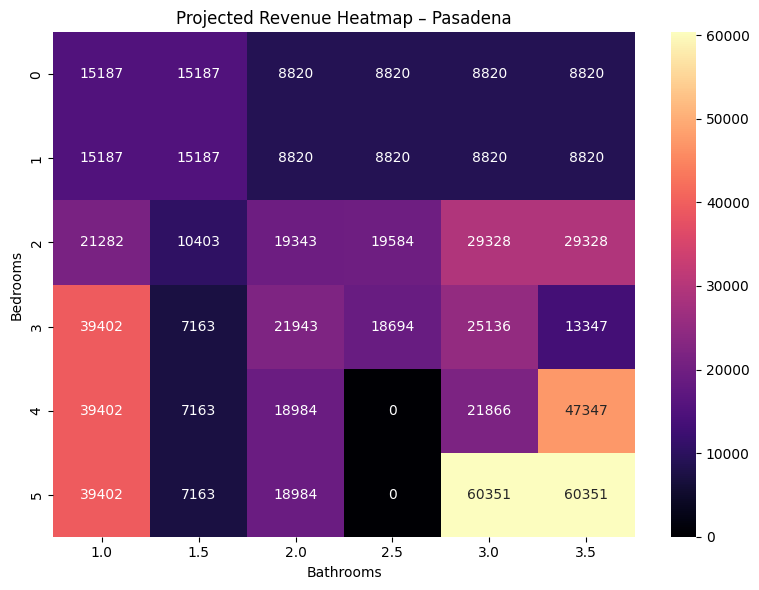

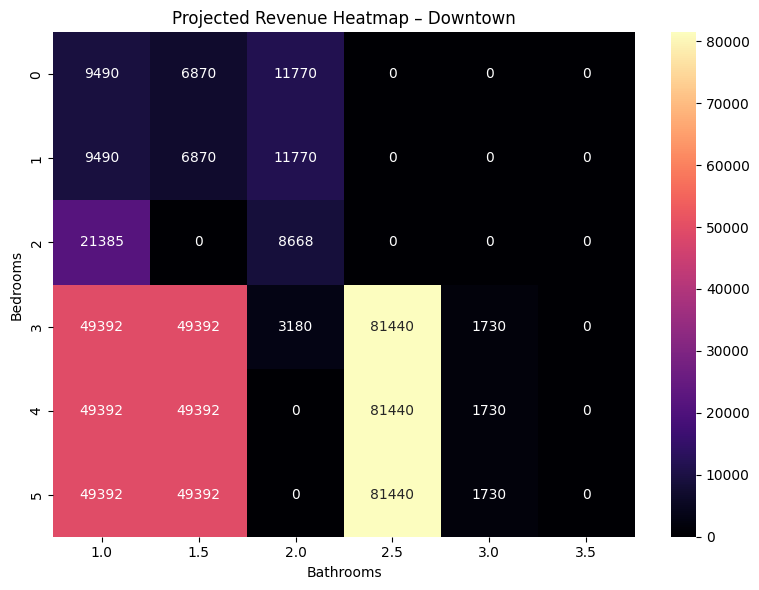

In [ ]:

# Ensure column names are correct
df = decision_tree_regressor_df.rename(columns={
    "Neighbourhood": "Neighbourhood",
    "Projected Revenue": "Projected Revenue"  # if needed
})

# Unique neighborhoods
neighs = df["Neighbourhood"].unique()

# Create one heat map per neighbourhood
for n in neighs:
    subset = df[df["Neighbourhood"] == n]

    # Pivot for heatmap
    pivot = subset.pivot_table(
        values="Projected Revenue",
        index="Bedrooms",
        columns="Bathrooms"
    )
    # Customised heat map
    plt.figure(figsize=(8,6))
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="magma")
    plt.title(f"Projected Revenue Heatmap – {n}")
    plt.xlabel("Bathrooms")
    plt.ylabel("Bedrooms")
    plt.tight_layout()
    plt.show()


**Exposition Park**

In Exposition Park, projected revenue generally increases as the number of bedrooms rises.
For example, small units such as 0–1 bedroom homes with 1 bathroom earn around 10,364, which is on the lower end.
However, when you move to 3–5 bedrooms with 1–2 bathrooms, projected revenue jumps sharply to 24,640–29,325, showing that larger homes perform significantly better here.
Bathrooms beyond 2.5 take away value in this neighbourhood, as revenue decreases.

**Hollywood Hills**

Hollywood Hills shows a much wider spread in potential revenue.
Smaller units with 0–1 bedrooms and 1 bathroom earn around 13,258, but certain mid-sized configurations see large jumps. For example, 2 bedrooms and 2 bathrooms yield about 30,470.
The highest values occur for 4 bedrooms with 3.5 bathrooms, reaching around 38,177, showing that luxury-sized homes can be especially profitable here.
Lower bathroom counts in large homes still earn well, but additional bathrooms tend to boost revenue further in this neighbourhood.

**Inglewood**

Inglewood’s revenue patterns vary more irregularly.
Small homes with 0–1 bedrooms and 1 bathroom earn around 8,989, while some mid-sized setups show moderate gains, like 3 bedrooms and 2 bathrooms earning 19,460.
The biggest spike occurs at 4 bedrooms and 2 bathrooms, where projected revenue peaks at about 44,976, the highest value in this neighbourhood.
Interestingly, comparing several configurations holding number of bedrooms stagnant while adding bathrooms shows drops in revenue, suggesting that bathrooms in Inglewood do not add value past a certain point.

**Pasadena**

Pasadena’s heatmap shows mostly modest projected revenue for smaller units.
Homes with 0–1 bedrooms and 1-1.5 bathrooms earn around 15,187, but revenue increases for mid-sized listings—for example, 2 bedrooms and 3 bathrooms reach around 29,328.
Larger properties show more dramatic jumps: 5 bedrooms and 3.5 bathrooms produce the highest value at roughly 60,351.
This indicates that larger property listings perform exceptionally well in Pasadena.

**Downtown**

Downtown has lower revenue potential for small units, with 0–1 bedroom homes earning 6,870–11,770.
There is a strong jump at 3–5 bedrooms with 1.5 bathrooms, each reaching around 49,392.
The peak revenue appears for 3–5 bedrooms with 2.5 bathrooms, where projections hit around 81,440, the highest across all Downtown combinations.


Note:
We chose to exclude projected revenues of 0 from interpretation. It's indeterminate whether these reflect a bedroom/bathroom combination that truly yields no projected revenue, or simply indicate that no listings with that configuration currently exist in the dataset for that neighbourhood.

Additionally, space limitations and certain sensabilities may be the reason for the absence of these configurations. For example, it may serve very little utility for properties with 0-1 bedrooms to have 3-3.5 bathrooms.

# 5. OLS Modeling

In [ ]:
dummy_cols = [col for col in combined_df.columns if col.startswith("neighbourhood")]
print(dummy_cols)

['neighbourhood_cleansed', 'neighbourhood_group_cleansed']


In [ ]:
#OLS Regression
import statsmodels.api as sm

X = model_df.drop('revenue', axis=1)
y = model_df['revenue']

# Convert boolean dummy columns to integer (0 or 1) for statsmodels
boolean_cols = X.select_dtypes(include='bool').columns
X[boolean_cols] = X[boolean_cols].astype(int)

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

robust_model = model.get_robustcov_results(cov_type='HC3')
print(robust_model.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     146.7
Date:                Mon, 08 Dec 2025   Prob (F-statistic):          5.21e-173
Time:                        13:00:32   Log-Likelihood:                -21854.
No. Observations:                1893   AIC:                         4.372e+04
Df Residuals:                    1886   BIC:                         4.376e+04
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [ ]:
# Creating a copy of the data specifically for the OLS model
ols_model_df = combined_df[['revenue', 'bedrooms', 'bathrooms', 'neighbourhood_cleansed']].copy()

# Adding the interaction term to the OLS to check if if the effect of bedrooms on revenue varies across neighbourhoods
import statsmodels.formula.api as smf

model_ols_int = smf.ols(
    'revenue ~ bedrooms * C(neighbourhood_cleansed) + bathrooms * C(neighbourhood_cleansed)',
    data=ols_model_df
).fit()

robust_model_int = model_ols_int.get_robustcov_results(cov_type='HC3')
print(robust_model_int.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.104
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     9.186
Date:                Mon, 08 Dec 2025   Prob (F-statistic):           7.23e-20
Time:                        13:00:32   Log-Likelihood:                -21828.
No. Observations:                1893   AIC:                         4.369e+04
Df Residuals:                    1878   BIC:                         4.377e+04
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [ ]:
# Testing for the joint significance of interaction term bedroom

constraint_string_bed = [
    "bedrooms:C(neighbourhood_cleansed)[T.Exposition Park] = 0",
    "bedrooms:C(neighbourhood_cleansed)[T.Hollywood Hills] = 0",
    "bedrooms:C(neighbourhood_cleansed)[T.Inglewood] = 0",
    "bedrooms:C(neighbourhood_cleansed)[T.Pasadena] = 0"
]

f_test_result = model_ols_int.f_test(constraint_string_bed)
print(f_test_result)

<F test: F=6.95936965548038, p=1.4699571992318527e-05, df_denom=1.88e+03, df_num=4>


In [ ]:
# rounding the results to 4 decimal places
f_test_result = model_ols_int.f_test(constraint_string_bed)

f_stat = round(f_test_result.fvalue, 4)
p_val = round(f_test_result.pvalue, 4)

print(f"F-statistic = {f_stat}, p-value = {p_val}")

F-statistic = 6.9594, p-value = 0.0


In [ ]:
# testing for joint significance of interaction term bathroom
constraint_string_bath = (
    "bathrooms:C(neighbourhood_cleansed)[T.Exposition Park] = 0, "
    "bathrooms:C(neighbourhood_cleansed)[T.Hollywood Hills] = 0, "
    "bathrooms:C(neighbourhood_cleansed)[T.Inglewood] = 0, "
    "bathrooms:C(neighbourhood_cleansed)[T.Pasadena] = 0"
)

f_test_result = model_ols_int.f_test(constraint_string_bath)
print(f_test_result)

<F test: F=2.1565698398777355, p=0.07159000606520394, df_denom=1.88e+03, df_num=4>


In [ ]:
# rounding the results to 4 decimal places
f_test_result = model_ols_int.f_test(constraint_string_bath)

f_stat = round(f_test_result.fvalue, 4)
p_val = round(f_test_result.pvalue, 4)

print(f"F-statistic = {f_stat}, p-value = {p_val}")

#not significant

F-statistic = 2.1566, p-value = 0.0716


OLS model without the interaction terms assumes the variables such as bedroom or bathroom have the exact effect on the revenue in LA. However, this assumption is not realistic, therefore we added interaction terms between (neighbourhood x bedrooms) and ( neighbourhood x bathrooms) for 5 Los Angeles districts, where our baseline neighbourhood is 'Downtown'. Additionally, we used robust standard errors to adjust for heteroscedasticity. Individually only Hollywood Hills neighbourhood gives significant effect for adding a bedroom, p-value= 0.014. Adding the bathroom in Downtown neighbourhood was close to being signifcant p-value=0.079.

By looking a the joint significance of interaction terms first for bedrooms and neighbourhoods, we see that together it has an impact on the revenue, despite the fact that seperately not every combination of bedroom and district shows a strong difference, compined it gives p-value=0.00, thus gives a pattern.
All togeteher it shows that the revenue-bedroom relationship in not the same everwhere. Some neighbourhoods like 'Hollywood Hills' drives revenue more that others.

For bathroom-neighbourhood relationship joint significance is not strong, p-value=0.0716. Both individually and together we cannot say that adding a bathroom will pull up the revenue. We cannot also claim that the realtionship is the same the same for each neighbourhood. The significance is slightly above 5%, therefore there might be some hiddent patterns for bathroom- neighbourhood relationship.

To sum up, the simple OLS regression provides a general understanding of how individual property features relate to revenue across Los Angeles. Bedrooms and bathrooms show a strong positive effect on revenue, and certain neighborhoods such as Hollywood Hills and Pasadena are associated with higher average earnings relative to the baseline area.
However, this model assumes that the impact of bedrooms and bathrooms is identical across all locations, which is not realistic in a diverse market like Los Angeles. Therefore, improved analysis requires incorporating location-specific effects through interaction terms to capture how the revenue  varies by neighborhood.

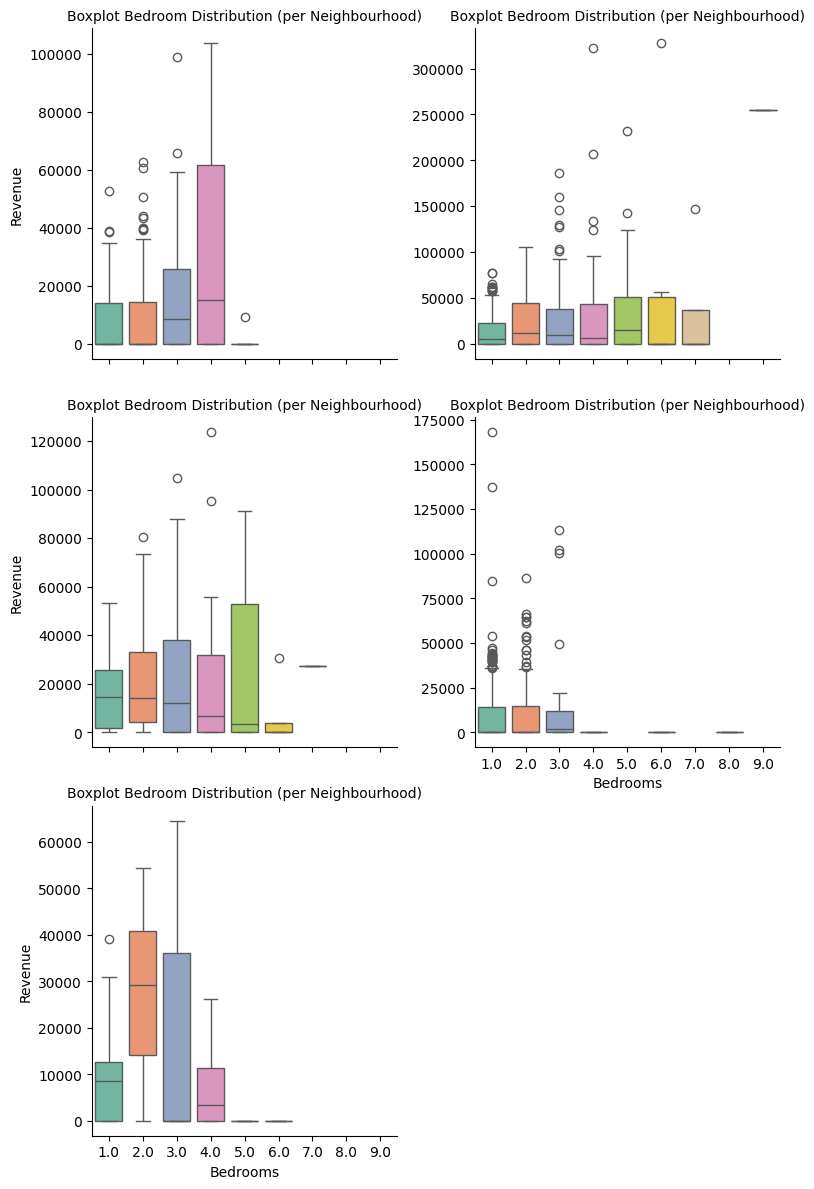

In [ ]:

ols_model_df['bedrooms'] = ols_model_df['bedrooms'].astype(float)

# Get sorted unique bedroom values as strings
bedroom_categories = sorted(ols_model_df['bedrooms'].unique())
bedroom_categories_str = [str(b) for b in bedroom_categories]

# Convert to string for categorical x-axis
ols_model_df['bedrooms_cat'] = ols_model_df['bedrooms'].astype(str)

# FacetGrid with ordered x-axis
g = sns.FacetGrid(ols_model_df, col="neighbourhood_cleansed", col_wrap=2, height=4, sharey=False)
g.map_dataframe(
    sns.boxplot,
    x="bedrooms_cat",
    y="revenue",
    order=bedroom_categories_str,  # enforce numerical order
    palette="Set2",
    hue='bedrooms'
)

g.set_axis_labels("Bedrooms", "Revenue")
g.set_titles("Boxplot Bedroom Distribution (per Neighbourhood)")
plt.show()

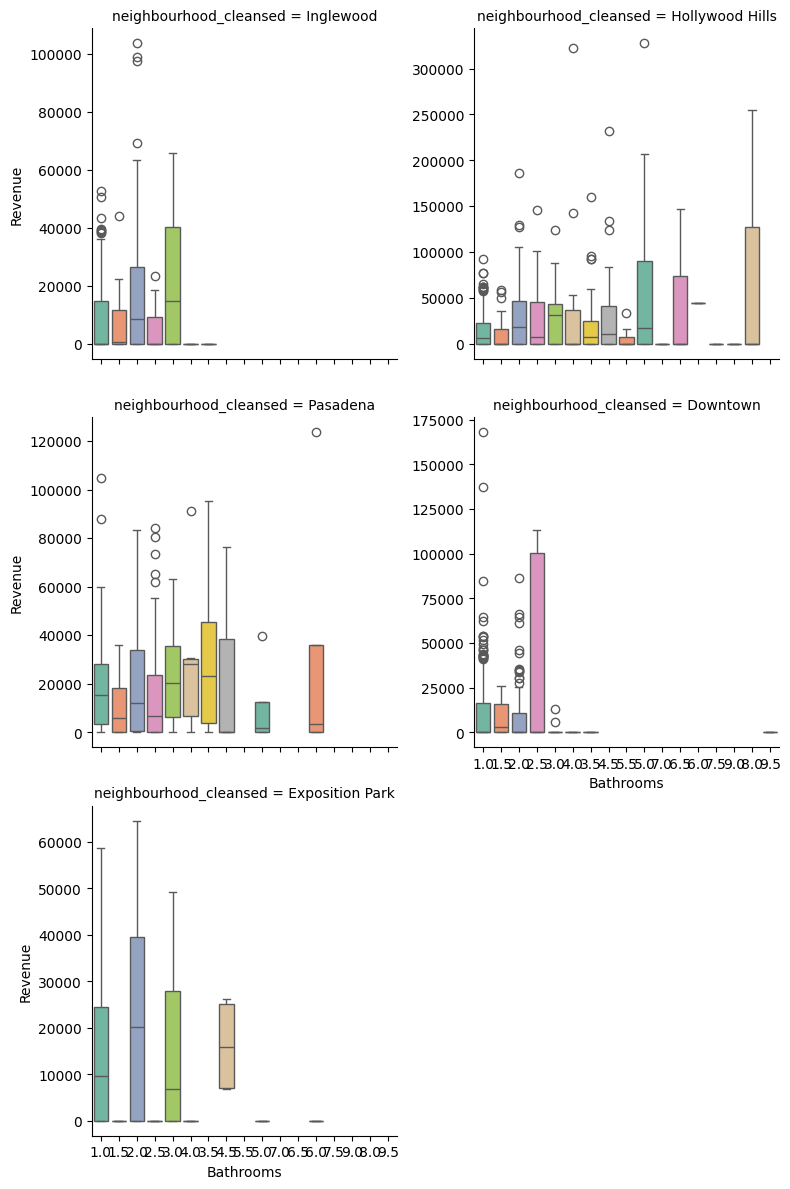

In [ ]:
# Convert to string so Seaborn treats it as categorical
ols_model_df['bathrooms_cat'] = ols_model_df['bathrooms'].astype(str)

# FacetGrid
g = sns.FacetGrid(ols_model_df, col="neighbourhood_cleansed", col_wrap=2, height=4, sharey=False)
g.map_dataframe(sns.boxplot, x="bathrooms_cat", y="revenue", palette="Set2", hue="bathrooms")

# Labels
g.set_axis_labels("Bathrooms", "Revenue")
plt.show()

##Boxplots: Bedrooms- Revenue and Bathroom-Revenu per Neighbourhood

**Overall Conclusions**

The revenue vary a lot across Los Angeles neighbourhoods, which is indicatted by the wide differences in IQR length in both bedrooms and bathrooms boxplots. Several neighbourhoods exhibit extreme outliers, suggesting that certain listings earn unusually high revenue. These outliers might be driven by location specific demand factors as  concerts, sport games, award events and other. It thus increase mean revenue without showing the typical performance of the factors.


**Exposition Park**

Revenue peaks with 1-2 bathroom combination, and with 3-4 bedrooms median drops significantly. 1 bathroom median revenue is at around 10k, median for 3 bathrooms is much lower than the 2 bathrooms, and even though 4.5 bathroom gives higher median it has lower maximum revenue value. This tell us that less space gives better revenue returns, than adding extra space in this neighbourhood.

**Pasadena**

With additional bedrooms, the revenue fall within normal revenue range, with only few giving exceptionally high revenue. Median slightly drops when changing from 2 to 3 bedroom and keeps decreasing when adding extra room. We can see some outliers for a place with 1 bathroom but it already gives quite high median revenue of around 18k. 4 bathrooms give the highest median but then it sharply drops. Mid-sized, quality accommodations perform the most consistently in Pasadena.

**Inglewood**

 Larger units tend to earn more, with revenue increasing for 3-4 bedroom properties. Smaller listings also display several high-revenue outliers, suggesting more the event-driven boosts rather than steady demand. Bathroom revenue peaks around 3 bathrooms but remains uneven overall. These patterns suggest that Inglewood benefits from large-scale events, that can significantly raise earnings for select hosts.


**Downtown**

Both boxplots for bedrooms and bathrooms reveal a pattern of many outliers for smaller spaces. The medians are often close to the first quartile, indicating that most listings generate relatively similar, modest revenue. Overall, the revenue distribution for bedrooms is dense, showing a relatively uniform pattern, although many high outliers are present. Listings with 1-2 bedrooms  perform reasonably well, but additional unit shows a decrease in revenue. Small number of bathrooms exhibit many outliers, and having 2.5 bathrooms shows high right skewness.This suggest that people prioritize location over space.

**Hollywood Hills**

Hollywood Hills features the largest number of bedrooms and bathrooms, which strongly influence revenue, reflecting the dominance of the luxury market. Median revenue rises noticeably with 1-4 bedrooms and then drops for larger units. Similarly, more bathrooms correspond to a clear upward shift in revenue with few exceptions. Luxury renters in this area pay a premium for space and amenities, which explains the presence of numerous high-revenue outliers.

# 6. Business insights

In [ ]:
average_revenue = model_df['revenue'].mean()
print("Average revenue across all properties:", average_revenue)

Average revenue across all properties: 15684.93502377179


In [ ]:
# Identify the one-hot encoded neighborhood columns
neigh_cols = [
    'neighbourhood_cleansed_Exposition Park',
    'neighbourhood_cleansed_Hollywood Hills',
    'neighbourhood_cleansed_Inglewood',
    'neighbourhood_cleansed_Pasadena',
    'neighbourhood_cleansed_Downtown'
]

model_df['neighbourhood_cleansed'] = model_df[neigh_cols].idxmax(axis=1)
model_df['neighbourhood_cleansed'] = model_df['neighbourhood_cleansed'].str.replace(
    'neighbourhood_cleansed_', ''
)

# Now compute averages
avg_by_neigh = model_df.groupby('neighbourhood_cleansed')['revenue'].mean()
print("Average revenue per neighborhood:", avg_by_neigh)

Average revenue per neighborhood: neighbourhood_cleansed
Downtown            9637.418790
Exposition Park    13619.241935
Hollywood Hills    23498.611111
Inglewood          11777.425926
Pasadena           18717.619048
Name: revenue, dtype: float64


We have prepared recommendations for the best and worst configurations for each of our 5 neighborhoods of exploration: Hollywood Hills, Inglewood, Downtown LA, Exposition Park, and Pasadena. While our analysis does not account for seasonal trends or the direct revenue effects of event occurrences, we felt that it was important to narrow to comparable areas for the most meaningful conclusions. Their similar structure surrounding major event venues suggests that they would experience parallel patterns of revenue fluctuation, supporting a fair comparative assessment.

In Exposition Park, we recommend investors focus on properties with 3-5 bedrooms and 1 bathroom, as these are the "hotspot" for highest predicted revenue. On the other hand, we recommend avoiding properties 0-2 bedrooms and 2.5-3.5 bathrooms, as they generate the lowest returns.

For Hollywood Hills, we recommend investing in properties with 4 bedrooms. The highest return occurred when this was matched with 3.5 bathrooms. However, 1-2.5 bathrooms also generated significant returns, and the tradeoff in cost to develop an additional bathroom should be considered.

In Inglewood, the highest returns are predicted to come from properties with 4 bedrooms and 2 bathrooms. With a considerable drop off, the next highest returns come from properties with 3 bedrooms and 3 bathrooms. In this neighborhood, we recommend avoiding 2 bedrooms/1.5 bathrooms and 0-2 bedrooms with 2.5-3.5 bathrooms.

For Pasadena, the "hotspot" can be found in 5 bedrooms with 3/3.5 bathrooms. However, these could have significant development costs that would reduce ROI. We recommend leaving aside properties with 3-5 bedrooms and 1.5 bathrooms.

Lastly, in Downtown LA, investing in 3-5 bedrooms with 2.5 bathrooms should lead to profitable returns. However, we urge investors to forego investing in an extra half bathroom, as 3-5 bedrooms with 3 bathrooms are predicted to generate the lowest returns for this neighborhood.

To further support our investment strategy, we additionally would like to present how our top configurations outperform global and neighborhood averages:

Exposition Park (3-5 bedrooms and 1 bathroom):
*   86.9% increase from global average
*   115.36% increase from Exposition Park average

Hollywood Hills (4 bedrooms and 3.5 bathrooms):
*   143.4% increase from global average
*   62.46% increase from Hollywood Hills average

Inglewood (4 bedrooms and 2 bathrooms):
*   186.7% increase from global average
*   281.8% increase from Inglewood average

Pasadena (5 bedrooms and 3/3.5 bathrooms):
*   284.7% increase from global average
*   222.58% increase from Pasadena average

Downtown LA (3-5 bedrooms and 2.5 bathrooms):
*   419.4% increase from global average
*   745% increase from Downtown average

Further, from these, we recommend investing in the Downtown LA top property over others, as that one performances the best in comparison to the global average and unique neighborhood average.

# 7. AI declaration

We confirm that all programming, analytical work, and problem-solving in this assignment have been carried out collaboratively by our group. Our use of artificial intelligence has been limited to appropriate academic support. Specifically, AI tools were used only to assist with academic writing in English, such as improving clarity, grammar, and structure.

In addition, we used AI tools, including the built-in Gemini function in Google Colab, solely to help us understand coding errors by providing explanations of error messages, as well as to support our understanding of the SHAP and OLS components of the code. All code written, modified, or implemented in this assignment is the original work of our group members, and all decisions regarding the design and execution of the programming tasks were made by the group.
